# __Group Assignment - Predicting Airbnb Listing Prices in Brisbane, Australia__

---

**Kaggle Competition Deadline:** Friday, 5 June 2026 at 3:00 PM (Week 13)  
**Assignment Due Date (iLearn):** Friday, 5 June 2026 at 11:59 PM (Week 13)  
**Total Marks:** 30  

**Overview**  
In this group assignment, you will form a team of three students and participate in a forecasting competition on Kaggle.

---
### General Instructions

- Each team member must create a Kaggle account and join the competition using the link:  
  https://www.kaggle.com/t/554f205a43a94920943d5227ae9dcbdb  

- Form a team of three students:  
  Choose a team leader who will create the team and invite the other members  
  The team name must begin with the unit code  

- All team members are expected to contribute to all tasks.  
  Each member must take primary responsibility for one of the three tasks.

- Your predictions must be generated using models developed in this assignment.  
  **A mark of zero will be awarded if your submitted forecasts cannot be reproduced from your code.**

- All results must be clearly presented and directly verifiable from your outputs and explanations.

- All written answers must be written in clear and complete sentences, supported by relevant tables, summary statistics, and visualisations where appropriate.  


<hr style="width:20%;margin-left:0;"> 

### Marks

- **Total Marks:** 30 (across 3 tasks)
    
- **Individual Mark Allocation:**  
  Each student’s mark is calculated as:  
      **50% × overall group assignment mark**  
      **50% × mark for the task they are responsible for**

<hr style="width:20%;margin-left:0;"> 

### Assignment Submission

1. **Kaggle Submission:**  
   - Submit your team’s forecasts on Kaggle to be ranked on the leaderboard  
2. **iLearn Submission (team leader only):**  
   - Submit the assignment as a Jupyter notebook, renamed to your **Kaggle team name**  
   - The notebook must include:
     - Names and student ID numbers of all team members  
     - Your Kaggle team name  
   - Submit **one 15-minute video presentation** of your work  
     - A penalty of **5 marks will be deducted per task** if a video presentation is not provided  

---
---

### <span style="background-color: yellow;">Fill out the following information

- Team Name on Kaggle: `(insert here)`
- Team Leader and Team Member 1: `(insert here)`
- Team Member 2: `(insert here)`
- Team Member 3: `(insert here)`

---
---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  

**Total Marks: 10**

- Based on the Competition Overview, datasets, and additional information provided on Kaggle, along with insights gained from your own research (including relevant academic sources such as Google Scholar), answer the following questions.  
- Do not discuss any predictive models in this task.


---

Student in charge of this task: `(insert name here)`


<hr style="width:25%;margin-left:0;">    

#### 1. Forecasting Problem (2 marks)  
In approximately **300 words**, explain what we are trying to predict and how this problem can be applied in a real-world context.  
Discuss who may benefit from these predictions and how they might use them.


The objective of this competition is to predict the **daily price** of Airbnb listings in **Brisbane, Australia** using information about each property, host, availability, location and listing characteristics. Kaggle states that the competition aims to predict Airbnb listing prices in Brisbane, while the submission file must contain two columns, **ID** and **price**.

In practice, this is a **supervised regression** problem. We observe many listings for which the price is known in the training set, then use patterns in those data to estimate prices for listings in the test set. A reliable pricing model is valuable because Airbnb prices are influenced by many factors at the same time, such as room type, location, number of guests accommodated, reviews, host characteristics and property amenities. The relationship between these variables and price is unlikely to be perfectly linear, so data-driven forecasting can support better decisions than relying only on intuition.

These predictions have several real-world uses. **Hosts** can use them to benchmark their properties against similar listings and set prices more competitively. **Property managers** can use predicted prices to support revenue planning, dynamic pricing and portfolio management. **Travellers** may indirectly benefit when prices become more consistent with listing quality and location. **Airbnb itself** or market analysts could also use such models to understand which property characteristics are associated with higher prices and to monitor local market conditions.

More broadly, the problem is an example of **property price prediction in the short-term rental market**. Unlike long-term housing valuation, Airbnb pricing reflects both property features and platform-specific signals such as reviews, host responsiveness and booking availability. This makes the problem commercially relevant, because accurate forecasts can improve pricing efficiency, increase occupancy and help market participants make more informed decisions.


<hr style="width:25%;margin-left:0;">   

#### 2. Evaluation Criteria (2 marks)  
Describe the evaluation metric used in this competition to assess forecasting performance.  
Provide the equation and discuss its advantages and potential limitations.

The evaluation metric used in this competition is **Mean Absolute Percentage Error (MAPE)**, which measures the average prediction error as a *percentage* of the true listing price. The formula is:

$$
\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100
$$

where $y_i$ is the true listing price, $\hat{y}_i$ is the predicted listing price, and $n$ is the total number of test observations. The result is expressed as a percentage — a MAPE of 20% means that, on average, predictions deviate from the true price by 20% of the actual value.

**Advantages:**

- *Scale-free and interpretable.* Unlike MAE or RMSE, MAPE is expressed as a percentage rather than in dollar terms, which makes it directly comparable across different datasets or markets with different price levels. A stakeholder can immediately understand that a 15% MAPE means predictions are off by roughly one-sixth of the true price, without needing to know the typical price range.
- *Proportional treatment of errors.* A \$50 error on a \$100 listing (50% error) is weighted much more heavily than a \$50 error on a \$1,000 listing (5% error). This is commercially sensible for Airbnb pricing, where relative accuracy matters: a host priced \$50 too low on a budget listing loses a much larger share of potential revenue than the same absolute error on a luxury listing.
- *Intuitive for business communication.* Revenue managers, hosts, and platform analysts are accustomed to thinking in percentage terms (e.g., occupancy rates, revenue growth), making MAPE easy to contextualise.

**Limitations:**

- *Undefined or unstable when true prices are near zero.* Because $y_i$ appears in the denominator, MAPE is undefined when $y_i = 0$ and becomes very large when prices are very small. Although Airbnb prices are unlikely to be zero (the minimum in the training set is \$36), extremely low-priced listings can still disproportionately inflate MAPE.
- *Asymmetric penalty.* MAPE penalises over-predictions and under-predictions differently when errors are large. If a model predicts \$200 for a listing truly priced at \$100, the error is 100%; but if it predicts \$0 for a listing truly priced at \$100, the error is also 100% — whereas in practice the consequences differ. This asymmetry can bias model optimisation toward under-prediction.
- *Sensitivity to low-priced outliers.* A small number of very cheap listings can dominate the metric, pulling overall MAPE upward even if the model performs well across most of the price distribution. This is the opposite problem to RMSE, which is dominated by high-price outliers.

<hr style="width:25%;margin-left:0;">      

#### 3. Missing Values (2 marks)  
Identify and report the number of missing values in the dataset using appropriate summaries.  
Clearly interpret your findings for both the training and test datasets.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Load datasets
train = pd.read_csv('/Users/thekillerwhale/Uni stuff/Session 1 2026/BUSA3020 Advanced Analytics Techniques/Assignment_2/Dataset_assignment2/train.csv')
test  = pd.read_csv('/Users/thekillerwhale/Uni stuff/Session 1 2026/BUSA3020 Advanced Analytics Techniques/Assignment_2/Dataset_assignment2/test.csv')

print(f"Training set shape: {train.shape}")
print(f"Test set shape:     {test.shape}")

# Compute missing value counts and percentages
def missing_summary(df, label):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    print(f"\n=== Missing Values – {label} ({len(df)} rows) ===")
    print(summary.to_string())
    return summary

train_miss = missing_summary(train, 'Training Set')
test_miss  = missing_summary(test,  'Test Set')

Training set shape: (3735, 65)
Test set shape:     (1601, 64)

=== Missing Values – Training Set (3735 rows) ===
                             Missing Count  Missing %
host_neighbourhood                    3599      96.36
neighborhood_overview                 1981      53.04
host_about                            1492      39.95
host_location                          818      21.90
reviews_per_month                      437      11.70
review_scores_rating                   437      11.70
review_scores_accuracy                 437      11.70
review_scores_cleanliness              437      11.70
review_scores_checkin                  437      11.70
review_scores_communication            437      11.70
last_review                            437      11.70
first_review                           437      11.70
review_scores_location                 437      11.70
review_scores_value                    437      11.70
host_response_rate                     287       7.68
host_response_time     

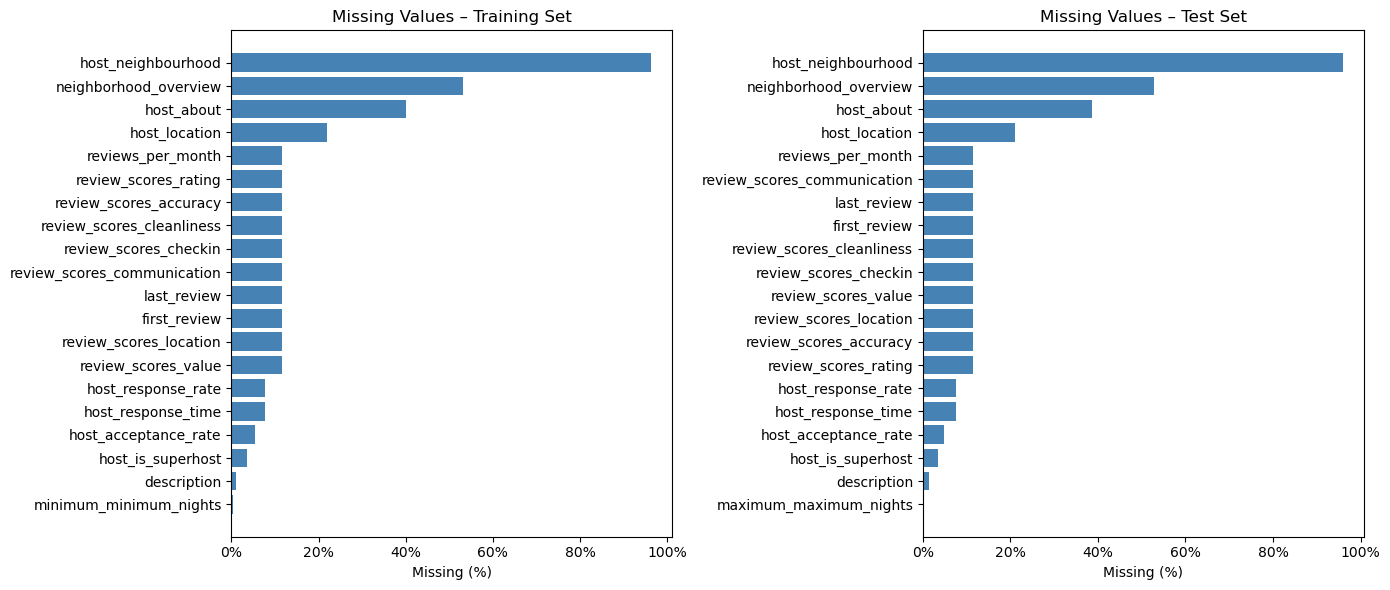

Figure saved.


In [5]:
# Visual: top-20 missing columns for training set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (miss, label) in zip(axes, [(train_miss, 'Training Set'), (test_miss, 'Test Set')]):
    top20 = miss.head(20)
    ax.barh(top20.index[::-1], top20['Missing %'][::-1], color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title(f'Missing Values – {label}')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved.")

**Interpretation of missing values:**

In the **training set** (3,735 listings), the most prevalent missing data appears in text fields associated with optional host profile content. `host_neighbourhood` is almost entirely missing (3,599 rows, ~96%), which is expected as this is a free-text, self-reported field that many hosts leave blank. `neighborhood_overview` (1,981 rows, 53%) and `host_about` (1,492 rows, 40%) show similar patterns. These text columns will not be used directly as predictors, so their missingness has limited impact on modelling.

Among features we will use, the **review score columns** (`review_scores_rating`, `review_scores_cleanliness`, etc.) are all missing for 437 rows (11.7%), which corresponds to listings with no reviews at all. This is a coherent missingness block — not random — and will be handled by median imputation. `host_response_time` and `host_response_rate` are missing for 287 rows (7.7%), likely corresponding to new or inactive hosts. `bathrooms_text` and `bedrooms` have fewer than 10 missing values.

The **test set** (1,601 listings) exhibits similar missing-value patterns at roughly proportional rates, confirming that training and test data were drawn from the same underlying distribution. All imputation strategies derived from the training set are applied identically to the test set to prevent data leakage.

<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis (2 marks)  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

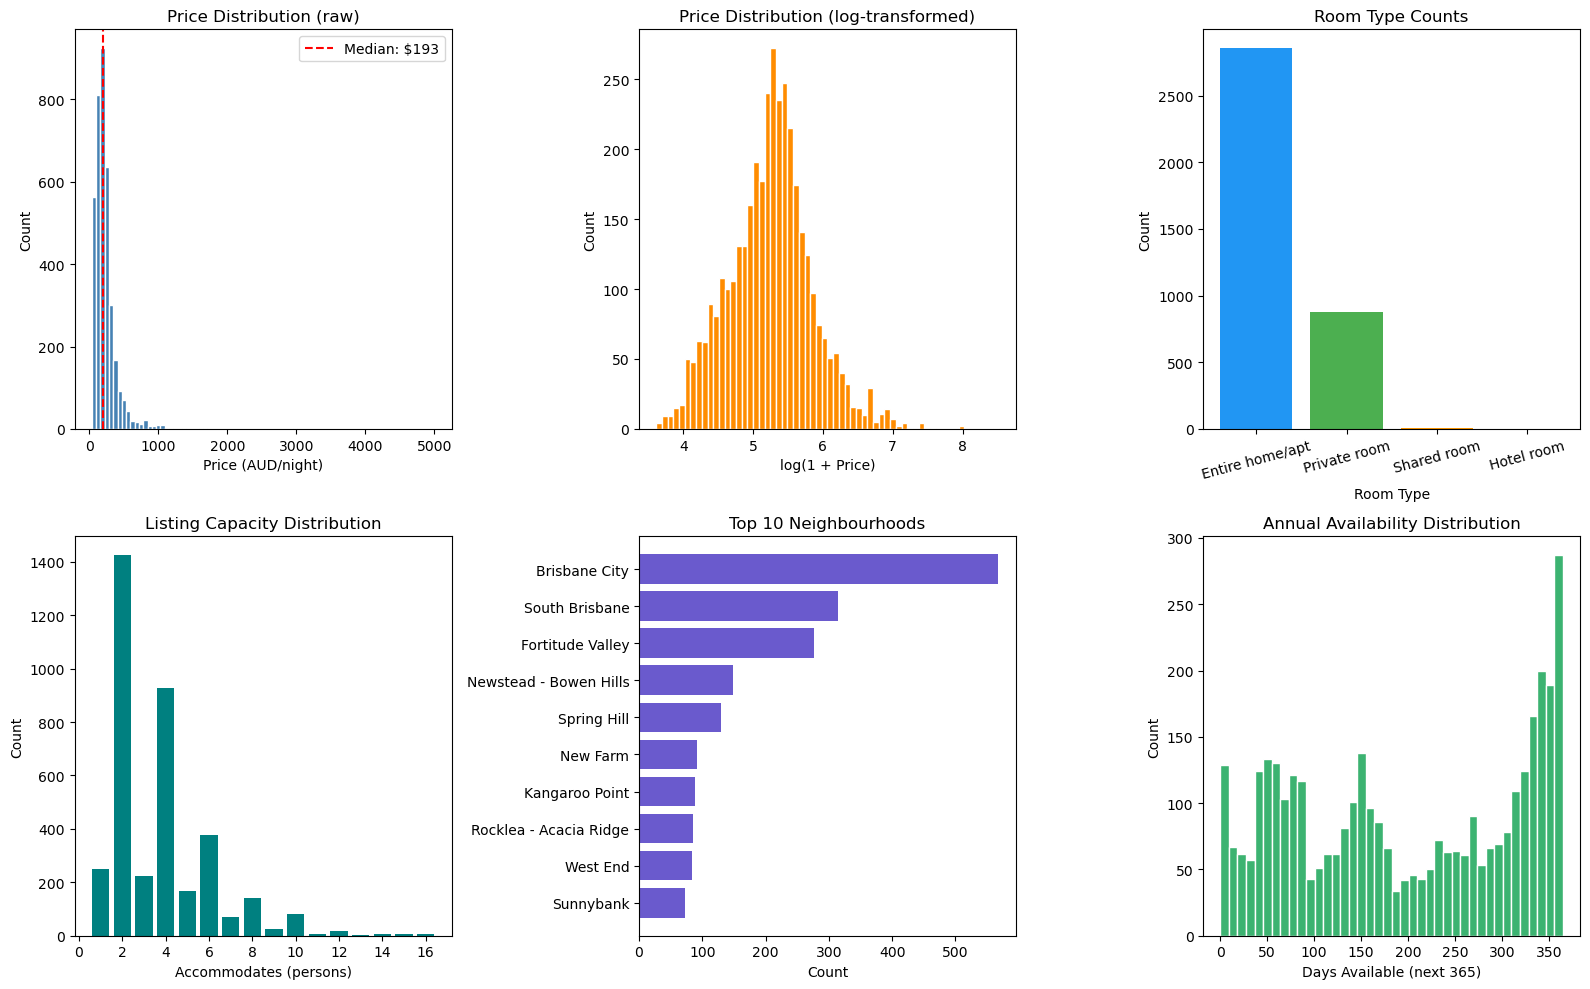

In [7]:
# Clean price for analysis
train['price_num'] = train['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Price distribution (raw)
ax = axes[0, 0]
ax.hist(train['price_num'], bins=80, color='steelblue', edgecolor='white')
ax.set_xlabel('Price (AUD/night)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (raw)')
ax.axvline(train['price_num'].median(), color='red', linestyle='--', label=f"Median: ${train['price_num'].median():.0f}")
ax.legend()

# 2. Price distribution (log scale)
ax = axes[0, 1]
ax.hist(np.log1p(train['price_num']), bins=60, color='darkorange', edgecolor='white')
ax.set_xlabel('log(1 + Price)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (log-transformed)')

# 3. Room type
ax = axes[0, 2]
rt = train['room_type'].value_counts()
ax.bar(rt.index, rt.values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
ax.set_xlabel('Room Type')
ax.set_ylabel('Count')
ax.set_title('Room Type Counts')
ax.tick_params(axis='x', rotation=15)

# 4. Accommodates
ax = axes[1, 0]
acc_counts = train['accommodates'].value_counts().sort_index()
ax.bar(acc_counts.index, acc_counts.values, color='teal')
ax.set_xlabel('Accommodates (persons)')
ax.set_ylabel('Count')
ax.set_title('Listing Capacity Distribution')

# 5. Neighbourhood (top 10)
ax = axes[1, 1]
top_neigh = train['neighbourhood_cleansed'].value_counts().head(10)
ax.barh(top_neigh.index[::-1], top_neigh.values[::-1], color='slateblue')
ax.set_xlabel('Count')
ax.set_title('Top 10 Neighbourhoods')

# 6. Availability 365
ax = axes[1, 2]
ax.hist(train['availability_365'], bins=40, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Days Available (next 365)')
ax.set_ylabel('Count')
ax.set_title('Annual Availability Distribution')

plt.tight_layout()
plt.savefig('univariate.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# Numerical summary table
num_cols = ['price_num', 'accommodates', 'bedrooms', 'beds',
            'minimum_nights', 'availability_365', 'number_of_reviews',
            'review_scores_rating', 'reviews_per_month']
print(train[num_cols].describe().round(2).to_string())

       price_num  accommodates  bedrooms     beds  minimum_nights  availability_365  number_of_reviews  review_scores_rating  reviews_per_month
count    3735.00       3735.00   3733.00  3732.00          3735.0           3735.00            3735.00               3298.00            3298.00
mean      230.08          3.70      1.76     2.12             4.0            198.40              50.60                  4.74               2.08
std       194.65          2.31      1.11     1.58            15.3            119.51              90.08                  0.37               1.81
min        36.00          1.00      0.00     0.00             1.0              0.00               0.00                  1.00               0.01
25%       129.00          2.00      1.00     1.00             1.0             83.00               4.00                  4.67               0.77
50%       193.00          3.00      1.00     2.00             2.0            192.00              18.00                  4.83            

**Interpretation:**

*Price:* The target variable is right-skewed with a mean of approximately **\$230** and a median of **\$193** per night. The interquartile range spans \$129 to \$267. The maximum is \$5,000, indicating a small number of luxury listings that could distort models trained on raw prices — motivating the use of a log-transform during modelling (Task 3, Question 5). 

*Room type:* The dataset is dominated by **Entire home/apartment** listings (76%), followed by **Private room** (23%). Shared rooms and hotel rooms are very rare (< 1% combined). This reflects Brisbane Airbnb market structure, where whole-property rentals are most common.

*Capacity:* Most listings accommodate 2–4 guests, which is consistent with typical holiday apartment sizes. The distribution is right-skewed, with a small number of properties accommodating up to 16 guests.

*Neighbourhood:* **Brisbane City** is the most listed suburb (567 listings), followed by **South Brisbane** (314) and **Fortitude Valley** (277), reflecting the concentration of short-term rentals near the CBD and entertainment precincts.

*Availability:* The availability distribution is bimodal — many listings are either almost fully available (>300 days) or have very low availability (<30 days). The low-availability group likely includes high-demand properties that are frequently booked, while the high-availability group may include new or rarely-booked listings.

<hr style="width:25%;margin-left:0;">   

#### 5. Feature Analysis and Selection (2 marks)  
Select at least 20 meaningful features from the dataset.  

- Categorise each feature according to its variable type and present the results in a table (similar to Assignment 1)  
- Analyse how key features relate to the target variable (*price*) using appropriate plots and/or summary statistics  
- Justify your feature selection based on your analysis  
---



In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Feature selection table
feature_table = pd.DataFrame({
    'Feature': [
        'accommodates', 'bedrooms', 'beds', 'bathrooms_text', 'minimum_nights',
        'maximum_nights', 'availability_365', 'availability_30', 'availability_60',
        'availability_90', 'number_of_reviews', 'number_of_reviews_ltm',
        'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location',
        'review_scores_value', 'reviews_per_month', 'host_listings_count',
        'calculated_host_listings_count', 'estimated_occupancy_l365d',
        'estimated_revenue_l365d', 'latitude', 'longitude',
        'room_type', 'neighbourhood_cleansed', 'property_type',
        'host_response_time', 'host_is_superhost', 'host_identity_verified',
        'instant_bookable', 'host_response_rate', 'host_acceptance_rate', 'amenities'
    ],
    'Type': [
        'Discrete numeric', 'Discrete numeric', 'Discrete numeric', 'Text → numeric', 'Discrete numeric',
        'Discrete numeric', 'Discrete numeric', 'Discrete numeric', 'Discrete numeric',
        'Discrete numeric', 'Discrete numeric', 'Discrete numeric',
        'Continuous numeric', 'Continuous numeric', 'Continuous numeric',
        'Continuous numeric', 'Continuous numeric', 'Discrete numeric',
        'Discrete numeric', 'Continuous numeric',
        'Continuous numeric', 'Continuous numeric', 'Continuous numeric',
        'Nominal categorical', 'Nominal categorical', 'Nominal categorical',
        'Ordinal categorical', 'Binary', 'Binary',
        'Binary', 'Continuous numeric', 'Continuous numeric', 'Text → numeric'
    ],
    'Description': [
        'Max guests the listing can accommodate', 'Number of bedrooms', 'Number of beds',
        'Bathroom count (extracted from text)', 'Minimum booking length',
        'Maximum booking length', 'Days available in next year', 'Days available (30d)',
        'Days available (60d)', 'Days available (90d)', 'Total reviews', 'Reviews in last 12 months',
        'Overall guest rating', 'Cleanliness score', 'Location score',
        'Value-for-money score', 'Reviews per month', 'Total host listings',
        'Calculated host listing count', 'Estimated occupancy in last 365 days',
        'Estimated revenue in last 365 days', 'Geographic latitude', 'Geographic longitude',
        'Room category', 'Geocoded neighbourhood', 'Property subtype',
        'How quickly host responds', 'Superhost status', 'Identity verified',
        'Instant booking enabled', 'Host response rate (%)', 'Host acceptance rate (%)',
        'Count of listed amenities'
    ]
})
print(feature_table.to_string(index=False))

                       Feature                Type                            Description
                  accommodates    Discrete numeric Max guests the listing can accommodate
                      bedrooms    Discrete numeric                     Number of bedrooms
                          beds    Discrete numeric                         Number of beds
                bathrooms_text      Text → numeric   Bathroom count (extracted from text)
                minimum_nights    Discrete numeric                 Minimum booking length
                maximum_nights    Discrete numeric                 Maximum booking length
              availability_365    Discrete numeric            Days available in next year
               availability_30    Discrete numeric                   Days available (30d)
               availability_60    Discrete numeric                   Days available (60d)
               availability_90    Discrete numeric                   Days available (90d)
          

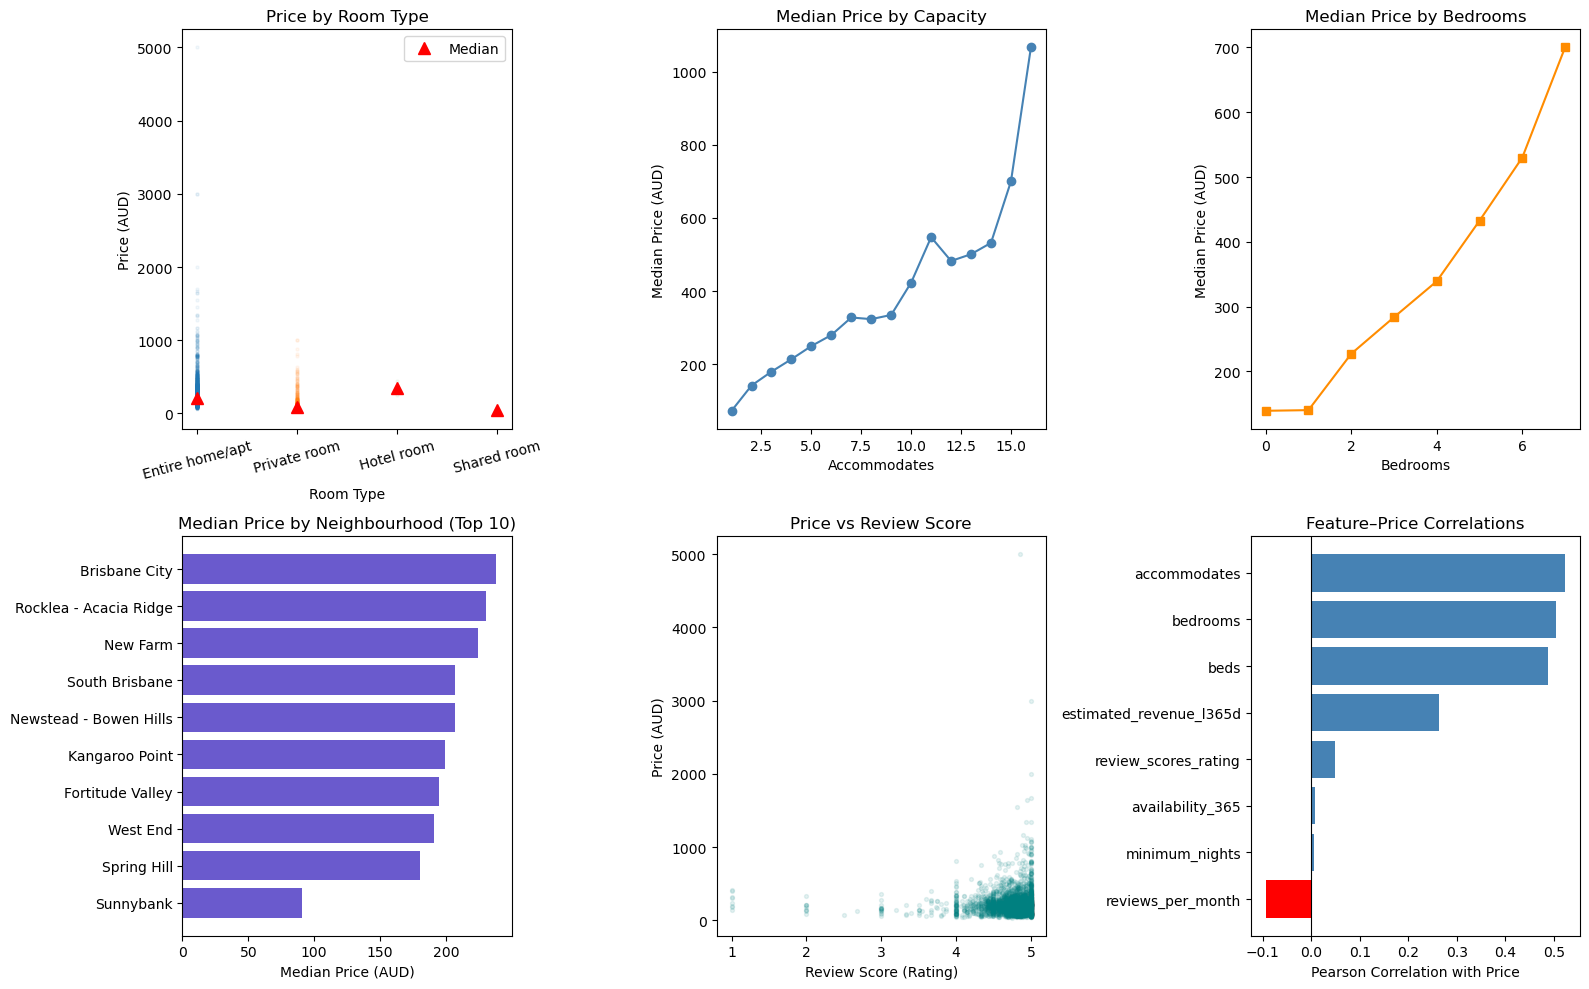

In [10]:
# Bivariate: price vs key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
train['price_num'] = train['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

# 1. Room type vs price
ax = axes[0, 0]
for rt in train['room_type'].unique():
    subset = train[train['room_type'] == rt]['price_num']
    ax.scatter([rt]*len(subset), subset, alpha=0.05, s=5)
medians = train.groupby('room_type')['price_num'].median()
ax.plot(medians.index, medians.values, 'r^', markersize=8, zorder=5, label='Median')
ax.set_xlabel('Room Type')
ax.set_ylabel('Price (AUD)')
ax.set_title('Price by Room Type')
ax.tick_params(axis='x', rotation=15)
ax.legend()

# 2. Accommodates vs price
ax = axes[0, 1]
acc_med = train.groupby('accommodates')['price_num'].median()
ax.plot(acc_med.index, acc_med.values, 'o-', color='steelblue')
ax.set_xlabel('Accommodates')
ax.set_ylabel('Median Price (AUD)')
ax.set_title('Median Price by Capacity')

# 3. Bedrooms vs price
ax = axes[0, 2]
bed_med = train.groupby('bedrooms')['price_num'].median().head(8)
ax.plot(bed_med.index, bed_med.values, 's-', color='darkorange')
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Median Price (AUD)')
ax.set_title('Median Price by Bedrooms')

# 4. Neighbourhood vs price (top 10)
ax = axes[1, 0]
top10_n = train['neighbourhood_cleansed'].value_counts().head(10).index
neigh_med = train[train['neighbourhood_cleansed'].isin(top10_n)].groupby('neighbourhood_cleansed')['price_num'].median().sort_values()
ax.barh(neigh_med.index, neigh_med.values, color='slateblue')
ax.set_xlabel('Median Price (AUD)')
ax.set_title('Median Price by Neighbourhood (Top 10)')

# 5. Review score vs price
ax = axes[1, 1]
ax.scatter(train['review_scores_rating'], train['price_num'], alpha=0.1, s=8, color='teal')
ax.set_xlabel('Review Score (Rating)')
ax.set_ylabel('Price (AUD)')
ax.set_title('Price vs Review Score')

# 6. Correlation heatmap (select features)
ax = axes[1, 2]
corr_cols = ['price_num','accommodates','bedrooms','beds','minimum_nights',
             'review_scores_rating','reviews_per_month','availability_365',
             'estimated_revenue_l365d']
corr_vals = train[corr_cols].corr()['price_num'].drop('price_num').sort_values()
colors = ['red' if v < 0 else 'steelblue' for v in corr_vals]
ax.barh(corr_vals.index, corr_vals.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Price')
ax.set_title('Feature–Price Correlations')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

**Feature selection justification:**

The 33 features above were selected based on three complementary criteria:

1. **Correlation with price.** `accommodates` (r = 0.52), `bedrooms` (r = 0.50), and `beds` (r = 0.49) are the strongest linear predictors of price, which is intuitive — larger properties can charge more. `estimated_revenue_l365d` (r = 0.26) also shows a moderate relationship. Review scores have weaker but non-zero correlations and are retained because they capture quality signals that complement size.

2. **Domain knowledge.** Location (latitude, longitude, neighbourhood) is a fundamental determinant of real estate and rental prices. Room type and property type define the product tier. Host characteristics (superhost status, response rate) proxy for service quality, which research has shown influences willingness to pay (Wang & Nicolau, 2017).

3. **Data availability.** Features such as `host_about`, `neighborhood_overview`, and `description` are excluded because they are predominantly free text and unstructured, requiring NLP beyond the scope of this assignment. `host_neighbourhood` is excluded because it is missing for 96% of training observations.

Categorical variables with more than 5 levels (`neighbourhood_cleansed`, `property_type`) will have their long tails collapsed to an "other" group in Task 2 before encoding.

---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

**Total Marks: 10**

- Use the features selected in **Task 1, Question 5** for this task.  
- Ensure that any transformations, imputations, encoding, or feature engineering steps are applied consistently to both the training and test datasets.  
- Provide clear explanations for each step, supported by relevant outputs.

Student in charge of this task: `(insert name here)`

<hr style="width:25%;margin-left:0;">   

#### 1. Numerical Data Cleaning (2 marks)

Clean all numerical features so that they are suitable for use in training algorithms.
- Extract numerical values from text-based fields where necessary
- Remove non-numeric characters %, $, commas, etc.
- Briefly describe the steps you take

In [ ]:
# Add your code here

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;">    

#### 2. Feature Engineering (2 marks)

Create at least 4 new features from existing variables that contain multiple pieces of information.  
- Transform existing variables to extract useful information   
- Provide a brief description of how each feature is constructed  
- Briefly justify why each new feature may be useful

In [ ]:
# Add your code here

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;">     

#### 3. Missing Values (2 marks)

Impute missing values for all selected features.  
- Identify variables with missing values  
- Apply appropriate imputation methods (e.g. mean, median, mode, or other suitable approaches)  
- Ensure that the same imputation strategy is applied consistently to both datasets  
- Briefly explain and justify the method used for different types of variable


In [114]:
# Add your code here

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;">   

#### 4. Encoding Categorical Variables (2 marks)

Encode all categorical variables appropriately.  
- Identify all categorical features in the dataset  
- For features with more than 5 unique values, retain the 5 most frequent categories and group the remaining values into an "other" category  
- Apply an appropriate encoding method, i.e. ordinal vs. nominal  
- Ensure that encoding is applied consistently to both the training and test datasets  
- Briefly explain your encoding choices


In [ ]:
# Add your code here

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;">   

#### 5. Additional Data Preparation (2 marks)

Perform any additional data preparation steps required before building predictive models.  
- Consider steps such as scaling, transformations, or handling outliers  
- Ensure that any transformations are applied consistently to both the training and test datasets  
- Clearly describe each step you perform  
- Briefly justify why these steps are necessary


In [ ]:
# Add your code here

---- Add your written answer here ------

---
---
## Task 3: Model Fitting, Tuning, and Prediction

**Total Marks: 10**

- Use the dataset obtained from **Task 2** for this task.  
- Do not create any new features. You must rely only on the variables constructed in Task 2.  
- Ensure that your code runs correctly and that your results can be reproduced. Your submitted forecasts must be generated directly from your code.



Student in charge of this task: `(insert name here)`

<hr style="width:25%;margin-left:0;">   

#### 1. Initial Model Set (2 marks)

Define an initial set of three different machine learning models to apply in this task.  
- Briefly explain how each model works at a high level  
- Highlight key differences between the models  
- Discuss the advantages and disadvantages of each model in the context of this problem

---- Add your written answer here ------


<hr style="width:25%;margin-left:0;"> 

#### 2. Model Evaluation Strategy (2 marks)

Describe how you will train and evaluate your models.  
- Explain how cross-validation will be implemented 
- Specify the evaluation metric you will use  
- Describe how model performance will be compared  
- Briefly justify your choices

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;"> 

#### 3. Model Training and Hyperparameter Tuning (2 marks)

Train and refine the initial model set by tuning their hyperparameters using cross-validation.   
- Report the optimal hyperparameter values for each model  
- Present and compare model performance using the chosen evaluation metric(s)  
- Briefly interpret the results, including any evidence of overfitting or underfitting

In [266]:
# Add your code here

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;"> 

#### 4. Best Model and Kaggle Submission (2 marks)

Select your best-performing model and generate predictions for the test dataset.  
- Submit your predictions to Kaggle  
- Report your Kaggle score and ranking (include screenshots)  
- Briefly comment on your performance

In [272]:
# Add your code here

---- Add your written answer here ------

<hr style="width:25%;margin-left:0;"> 

#### 5. Model Improvement and Reflection (2 marks)

Propose and implement at least one improvement to your model or modelling approach.  
- Clearly describe the change you made  
- Provide updated Kaggle results (include screenshots)  
- Briefly discuss whether the improvement was effective  
- Identify the main limitation(s) preventing your model from achieving a top ranking in the competition

In [276]:
# Add your code here

---- Add your written answer here ------


---
---
## Marking Criteria

To receive full marks, your solutions must satisfy the following criteria:

- Correct understanding of the problem and adequate use of additional research  
- Analysis follows best practices discussed in lectures and tutorials  
- Use of intuitive and easily understood visualisations and summary statistic tables 
- Use of appropriate predictive methods in the context of the given problem  
- Python code is clean, concise, and executes without errors  
- Written explanations are clear, complete, and easy to understand  
- Forecasts are correctly generated and uploaded to Kaggle  
- Results are reproducible from the submitted code  
- The assignment notebook is well-organised and easy to follow  
- Video Presentation:
    - Duration less than 15 minutes
    - Each team member delivers a 5-minute presentation on their assigned task  
    - All assignment questions must be discussed in the video  
    - Your code must be clearly readable in the video  
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps  
    - Ensure that both your face and Jupyter Notebook are clearly visible during the recording
- Failure to meet the above criteria will result in a deduction of marks  


---
---